# Homework06

Exercises to practice pandas, data analysis and regression

## Goals

- Understand the effects of pre-processing data
- Get familiar with the ML flow: encode -> normalize -> train -> evaluate
- Understand the difference between regression and classification tasks
- Build intuition for different regression models

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [ ]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor

from data_utils import object_from_json_url
from data_utils import regression_error

### Load Dataset

Let's load up the full [ANSUR](https://www.openlab.psu.edu/ansur2/) dataset that we looked at briefly in [Week 02](https://github.com/DM-GY-9103-2024F-H/WK02).

This is the dataset that has anthropometric information about U.S. Army personnel.

#### WARNING

Like we mentioned in class, this dataset is being used for these exercises due to the level of detail in the dataset and the rigorous process that was used in collecting the data.

This is a very specific dataset and should not be used to draw general conclusions about people, bodies, or anything else that is not related to the distribution of physical features of U.S. Army personnel.

In [ ]:
# Load Dataset
ANSUR_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur.json"
ansur_data = object_from_json_url(ANSUR_FILE)

# Look at first 2 records
ansur_data[:2]

#### Nested data

This is that *nested* dataset from Week 02.

# 🤔

Let's load it into a `DataFrame` to see what happens.

In [ ]:
# Read into DataFrame
ansur_df = pd.DataFrame.from_records(ansur_data)
ansur_df.head()


# 😓🙄

That didn't work too well. We ended up with objects in our columns.

Luckily, our `DataFrame` library has a function called [`json_normalize()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.json_normalize.html) that can help.

In [ ]:
# Read into DataFrame
ansur_df = pd.json_normalize(ansur_data)
ansur_df.head()

Much better. `DataFrames` are magic.

#### Data Exploration

Before we start creating models, let's do a little bit of data analysis and get a feeling for the shapes, distributions and relationships of our data.

1. Print `min`, `max` and `average` values for all of the features.
2. Print `covariance` tables for `age`, `ear.length` and `head.circumference`.
3. Plot `age`, `ear.length` and `head.circumference` versus the $1$ *feature* that is most correlated to each of them.

Don't forget to *encode* and *normalize* the data.

In [ ]:
# Work on Data Exploration here

### Encode non-numerical features
gender = ['F','M']
ansur_encoder = OrdinalEncoder(categories=[gender])
g_vals = ansur_encoder.fit_transform(ansur_df[["gender"]].values)
ansur_df[["gender"]] = g_vals


## 1. Print min, max, avg
ansur_features = list(ansur_encoded_df.columns)
for f in ansur_features:
  print(f)
  print("\tmin:", ansur_encoded_df[f].min())
  print("\tmax:", ansur_encoded_df[f].max())
  print("\tavg:", ansur_encoded_df[f].mean())

### Normalize all data
ansur_scaler = StandardScaler().set_output(transform="pandas")
ansur_scaled_df = ansur_scaler.fit_transform(ansur_encoded_df)

## 2. Print Covariances
ansur_scaled_df.cov()

## 3. Plot features most correlated to age, ear length and head circumference
plt.scatter(ansur_scaled_df["ear.length"], ansur_scaled_df["age"], alpha=0.3)
plt.xlabel("ear.length")
plt.ylabel("age")
plt.show()

plt.scatter(ansur_scaled_df["weight"], ansur_scaled_df["ear.length"], alpha=0.3)
plt.xlabel("weight")
plt.ylabel("ear.length")
plt.show()

plt.scatter(ansur_scaled_df["head.height"], ansur_scaled_df["head.circumference"], alpha=0.3)
plt.xlabel("head.height")
plt.ylabel("head.circumference")
plt.show()

ansur_scaled_df.cov()['weight']


### Interpretation

<span style="color:hotpink;">
Does anything stand out about these graphs? Or the correlations?<br>
Are correlations symmetric? Does the feature most correlated to ear length also have ear length as its most correlated pair?
</span>

The graph shows that head.circumference and head.height has a positive correlation; ear.length and weight also has a positive correlation, while age and ear.length has no correlation.
Correlations are relatively symmetric.
No. weight is most correlated to ear.length, but the feature most correlated to weight is hand.breadth instead of ear.length


### Regression

Now, we want to create a regression model to predict `head.circumference` from the data.

From our [Week 06](https://github.com/PSAM-5020-2026S-A/WK06) notebook, we can create a regression model by following these steps:

1. Load dataset (done! 🎉)
2. Encode label features as numbers (done! ⚡️)
3. Normalize the data (done! 🍾)
4. Separate the outcome variable and the input features
5. Create a regression model using all features
6. Run model on training data and measure error
7. Plot predictions and interpret results
8. Run model on test data, measure error, plot predictions, interpret results

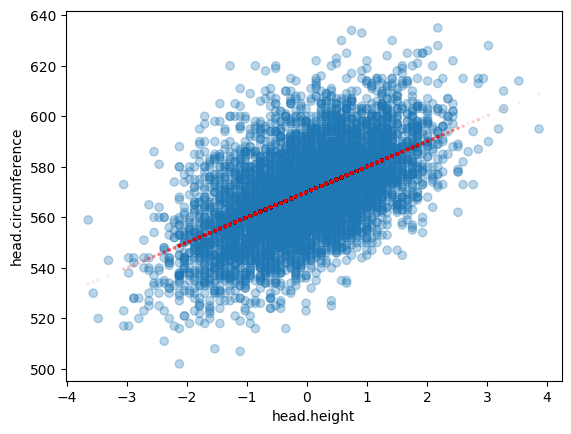

In [54]:
# Work on Regression Model here

## Separate outcome variable and input features
head_h = ansur_scaled_df[["head.height"]]
head_c = ansur_df["head.circumference"]

## Create a regression model
head_model = LinearRegression().fit(head_h, head_c)

## Measure error on training data
predicted_head_c = head_model.predict(head_h)
regression_error(ansur_df["head.circumference"], predicted_head_c)

## Plot predictions and interpret results
plt.scatter(head_h, head_c, marker='o', linestyle='', alpha=0.3)
plt.xlabel("head.height")
plt.ylabel("head.circumference")

plt.scatter(head_h, predicted_head_c, color='r', marker='o', linestyle='', alpha=0.05, s=3)
plt.xlabel("head.height")
plt.ylabel("head.circumference")
plt.show()

In [ ]:
## Load Test Data
ANSUR_TEST_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur-test.json"

ansur_test_data = object_from_json_url(ANSUR_TEST_FILE)
ansur_test_df = pd.json_normalize(ansur_test_data)

ansur_test_encoded_df = ansur_test_df.copy()

g_vals = ansur_encoder.transform(ansur_test_df[["gender"]])
ansur_test_encoded_df[["gender"]] = g_vals

ansur_test_scaled_df = ansur_scaler.transform(ansur_test_encoded_df)

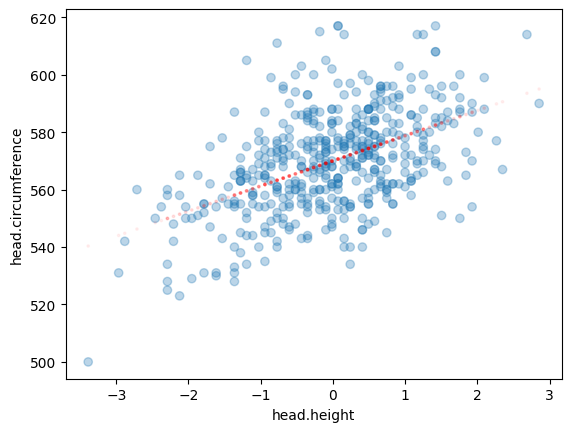

In [55]:
## Run model on test data
head_h = ansur_test_scaled_df[["head.height"]]
head_c = ansur_test_df["head.circumference"]

head_model = LinearRegression().fit(head_h, head_c)
predicted_head_c = head_model.predict(head_h)

## Measure error on test data
regression_error(ansur_test_df["head.circumference"], predicted_head_c)

## Plot predictions and interpret results
plt.scatter(head_h, head_c, marker='o', linestyle='', alpha=0.3)
plt.xlabel("head.height")
plt.ylabel("head.circumference")

plt.scatter(head_h, predicted_head_c, color='r', marker='o', linestyle='', alpha=0.05, s=3)
plt.xlabel("head.height")
plt.ylabel("head.circumference")
plt.show()

### Interpretation

<span style="color:hotpink;">
How well does your model perform?<br>
How could you improve it?<br>
Are there ranges of circumferences that don't get predicted well?
</span>

<span style="color:hotpink;">EDIT THIS CELL WITH ANSWER</span>